In [ ]:
# Download the dataset
# The URL is extracted from cell 8BFxxAkZ94w7
dataset_url = "https://zenodo.org/records/19334278/files/MultiClinAI-training+NER_test_bg+CORPUS_test_bg_v1.3_260330.zip?download=1"
!wget "{dataset_url}" -O dataset.zip

--2026-05-31 13:38:32--  https://zenodo.org/records/19334278/files/MultiClinAI-training+NER_test_bg+CORPUS_test_bg_v1.3_260330.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.43.153, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3108231547 (2.9G) [application/octet-stream]
Saving to: ‘dataset.zip’

dataset.zip         100%[===================>]   2.89G  17.8MB/s    in 2m 51s  

2026-05-31 13:41:24 (17.3 MB/s) - ‘dataset.zip’ saved [3108231547/3108231547]



In [ ]:
cd MultiClinNER-XLMR/


/content/MultiClinNER-XLMR


In [ ]:
import sys
import os
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
sys.path.insert(0, str(REPO_ROOT / 'src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_from_disk
from transformers import DataCollatorForTokenClassification, Trainer, TrainingArguments

from dataset import id2label
from model import load_model, compute_metrics, compute_class_weights, WeightedLossTrainer
from utils import tokenizer

OUTPUT_DIR   = REPO_ROOT / 'outputs' / 'checkpoints'
RESULTS_DIR  = REPO_ROOT / 'outputs' / 'results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING  : No GPU detected — training will be slow')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


In [ ]:
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed' / 'joint'
if not PROCESSED_DIR.exists():
    raise FileNotFoundError(
        f'Processed dataset not found at {PROCESSED_DIR}.\n'
        'Run notebooks/02_preprocessing.ipynb first.'
    )

joint_ds = load_from_disk(str(PROCESSED_DIR))
print('Dataset loaded:')
print(joint_ds)
print(f'\nTrain size : {len(joint_ds["train"])} sentences')
print(f'Dev size   : {len(joint_ds["validation"])} sentences')

model = load_model('xlm-roberta-base')
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel      : xlm-roberta-base')
print(f'Parameters : {total_params:,} total  |  {trainable:,} trainable')

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

Dataset loaded:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 20163
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2315
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2250
    })
})

Train size : 20163 sentences
Dev size   : 2315 sentences


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model      : xlm-roberta-base
Parameters : 277,458,439 total  |  277,458,439 trainable


In [ ]:
USE_FP16   = torch.cuda.is_available()
# T4 16 GB: batch=32 fp16 uses ~6 GB total — no accumulation needed.
BATCH_SIZE = 32
GRAD_ACCUM = 1
NUM_EPOCHS = 8   # increased from 5: more epochs needed with corrected class weights

total_steps  = (len(joint_ds['train']) // (BATCH_SIZE * GRAD_ACCUM)) * NUM_EPOCHS
warmup_steps = int(total_steps * 0.1)

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    # Cosine decay smoothly anneals LR to near-zero — better late-epoch
    # convergence than linear decay when training for 8 epochs.
    lr_scheduler_type='cosine',
    optim='adamw_torch',
    gradient_checkpointing=False,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='overall_f1',
    greater_is_better=True,
    fp16=USE_FP16,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    logging_steps=50,
    report_to='none',
    seed=42,
)

steps_per_epoch = len(joint_ds['train']) // (BATCH_SIZE * GRAD_ACCUM)
print(f'Effective batch : {BATCH_SIZE * GRAD_ACCUM}')
print(f'Steps per epoch : ~{steps_per_epoch}')
print(f'Total steps     : ~{steps_per_epoch * NUM_EPOCHS}')
print(f'Warmup steps    : {warmup_steps}')
print(f'Mixed precision : {USE_FP16}')
print(f'LR scheduler    : cosine')

Effective batch : 32
Steps per epoch : ~630
Total steps     : ~5040
Warmup steps    : 504
Mixed precision : True
LR scheduler    : cosine


In [ ]:
# Compute per-class weights capped at 5× the minimum weight.
# Pure inverse-frequency gives 60-70× ratios → model predicts entities everywhere
# (recall ~0.70, precision ~0.17, F1 ~0.27). Capping at 5× keeps entity signal
# without destroying precision.
MAX_WEIGHT_RATIO = 5.0
class_weights = compute_class_weights(joint_ds['train'], max_ratio=MAX_WEIGHT_RATIO)
print(f'Class weights (capped at {MAX_WEIGHT_RATIO}× min):')
for i, w in enumerate(class_weights.tolist()):
    print(f'  {id2label[i]:<8} {w:.3f}')

trainer = WeightedLossTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=joint_ds['train'],
    eval_dataset=joint_ds['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('\nStarting training ...')
trainer.train()

best_model_path = OUTPUT_DIR / 'best_model'
trainer.save_model(str(best_model_path))
print(f'\nBest model saved to {best_model_path}')

Class weights (capped at 5.0× min):
  O        0.163
  B-DIS    0.815
  I-DIS    0.815
  B-SYM    0.815
  I-SYM    0.815
  B-PRO    0.815
  I-PRO    0.815

Starting training ...


Epoch,Training Loss,Validation Loss,Precision,Recall,Overall F1
1,0.685302,0.676297,0.180638,0.604900,0.278199
2,0.620265,0.626296,0.197068,0.666053,0.304147
3,0.557234,0.621466,0.207044,0.694050,0.318944
4,0.517710,0.626964,0.211161,0.689998,0.323363
5,0.487073,0.655958,0.213314,0.681709,0.324948
6,0.458245,0.680250,0.210676,0.680420,0.321735
7,0.439332,0.699617,0.216052,0.682262,0.328180
8,0.440396,0.701336,0.215663,0.679683,0.327432


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best model saved to /content/MultiClinNER-XLMR/outputs/checkpoints/best_model


Saved: /content/MultiClinNER-XLMR/outputs/results/training_curves.png


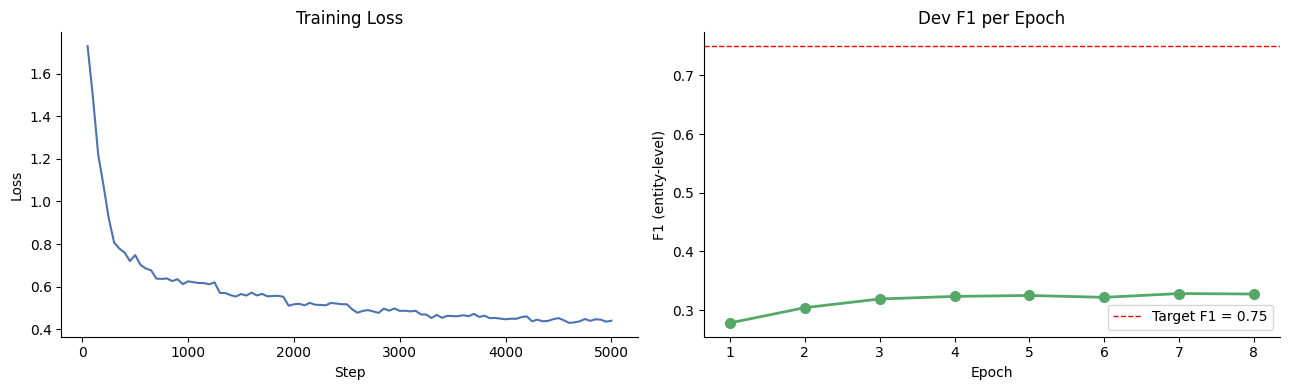


Best dev F1 : 0.3282  (epoch 7)


In [ ]:
log_history = pd.DataFrame(trainer.state.log_history)

train_log = log_history.dropna(subset=['loss']).copy()
eval_log  = log_history.dropna(subset=['eval_overall_f1']).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_log['step'], train_log['loss'], color='#4C72B0', linewidth=1.5)
ax1.set(xlabel='Step', ylabel='Loss', title='Training Loss')
ax1.spines[['top', 'right']].set_visible(False)

ax2.plot(eval_log['epoch'], eval_log['eval_overall_f1'],
         marker='o', color='#55A868', linewidth=2, markersize=7)
ax2.axhline(0.75, color='red', linestyle='--', linewidth=1, label='Target F1 = 0.75')
ax2.set(xlabel='Epoch', ylabel='F1 (entity-level)', title='Dev F1 per Epoch')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
curve_path = RESULTS_DIR / 'training_curves.png'
plt.savefig(str(curve_path), dpi=150, bbox_inches='tight')
print(f'Saved: {curve_path}')
plt.show()

best_f1 = eval_log['eval_overall_f1'].max()
best_ep = eval_log.loc[eval_log['eval_overall_f1'].idxmax(), 'epoch']
print(f'\nBest dev F1 : {best_f1:.4f}  (epoch {best_ep:.0f})')

In [ ]:
from seqeval.metrics import classification_report

preds_out   = trainer.predict(joint_ds['validation'])
logits, labels = preds_out.predictions, preds_out.label_ids
predictions = np.argmax(logits, axis=2)

true_labels = [[id2label[l] for l in seq if l != -100] for seq in labels]
true_preds  = [[id2label[p] for (p, l) in zip(ps, ls) if l != -100]
               for ps, ls in zip(predictions, labels)]

print('=== Dev set results (EN) ===')
print(classification_report(true_labels, true_preds))

=== Dev set results (EN) ===
              precision    recall  f1-score   support

         DIS       0.24      0.69      0.35      1997
         PRO       0.20      0.70      0.31      1588
         SYM       0.21      0.66      0.32      1844

   micro avg       0.22      0.68      0.33      5429
   macro avg       0.22      0.68      0.33      5429
weighted avg       0.22      0.68      0.33      5429



In [ ]:
import sys
import os
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from datasets import load_from_disk
from transformers import (
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    Trainer,
)
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix

from dataset import id2label, LABEL_LIST
from utils import tokenizer

BEST_MODEL_PATH = REPO_ROOT / 'outputs' / 'checkpoints' / 'best_model'
RESULTS_DIR     = REPO_ROOT / 'outputs' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f'Best model not found at {BEST_MODEL_PATH}.\n'
        'Complete Phase 4 training first.'
    )
print(f'Model path : {BEST_MODEL_PATH}')
print(f'Results dir: {RESULTS_DIR}')

Model path : /content/MultiClinNER-XLMR/outputs/checkpoints/best_model
Results dir: /content/MultiClinNER-XLMR/outputs/results


In [ ]:
model = AutoModelForTokenClassification.from_pretrained(str(BEST_MODEL_PATH))
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    processing_class=tokenizer,
    data_collator=data_collator,
)


def predict_on_split(lang, split='test'):
    """Run inference and return (true_labels, true_preds) as BIO string lists."""
    ds = load_from_disk(str(REPO_ROOT / 'data' / 'processed' / lang))
    preds_out = trainer.predict(ds[split])
    logits, labels = preds_out.predictions, preds_out.label_ids
    predictions = np.argmax(logits, axis=2)
    true_labels = [
        [id2label[l] for l in seq if l != -100]
        for seq in labels
    ]
    true_preds = [
        [id2label[p] for (p, l) in zip(ps, ls) if l != -100]
        for ps, ls in zip(predictions, labels)
    ]
    return true_labels, true_preds


print('Model loaded. Ready for evaluation.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded. Ready for evaluation.


In [ ]:
print('Running inference on EN test set ...')
en_true, en_pred = predict_on_split('en', 'test')

print('\n=== English Test Results ===')
print(classification_report(en_true, en_pred))

en_report = classification_report(en_true, en_pred, output_dict=True)

# Build a readable per-entity table
en_rows = []
for entity in ['DIS', 'SYM', 'PRO']:
    row = en_report.get(entity, {})
    en_rows.append({
        'Entity': entity,
        'Precision': round(row.get('precision', 0), 4),
        'Recall':    round(row.get('recall',    0), 4),
        'F1':        round(row.get('f1-score',  0), 4),
        'Support':   int(row.get('support',     0)),
    })
en_df = pd.DataFrame(en_rows)
en_overall_f1 = f1_score(en_true, en_pred)
print(f'\nOverall entity F1 (EN): {en_overall_f1:.4f}')
en_df

Running inference on EN test set ...



=== English Test Results ===
              precision    recall  f1-score   support

         DIS       0.26      0.66      0.37      2204
         PRO       0.20      0.70      0.32      1620
         SYM       0.19      0.64      0.30      1789

   micro avg       0.22      0.67      0.33      5613
   macro avg       0.22      0.67      0.33      5613
weighted avg       0.22      0.67      0.33      5613


Overall entity F1 (EN): 0.3304


,Entity,Precision,Recall,F1,Support
0,DIS,0.2609,0.6647,0.3747,2204
1,SYM,0.1941,0.6423,0.2981,1789
2,PRO,0.2047,0.6988,0.3167,1620


In [ ]:
print('Running inference on ES test set ...')
es_true, es_pred = predict_on_split('es', 'test')

print('\n=== Spanish Test Results ===')
print(classification_report(es_true, es_pred))

es_report = classification_report(es_true, es_pred, output_dict=True)

es_rows = []
for entity in ['DIS', 'SYM', 'PRO']:
    row = es_report.get(entity, {})
    es_rows.append({
        'Entity': entity,
        'Precision': round(row.get('precision', 0), 4),
        'Recall':    round(row.get('recall',    0), 4),
        'F1':        round(row.get('f1-score',  0), 4),
        'Support':   int(row.get('support',     0)),
    })
es_df = pd.DataFrame(es_rows)
es_overall_f1 = f1_score(es_true, es_pred)
print(f'\nOverall entity F1 (ES): {es_overall_f1:.4f}')
es_df

Running inference on ES test set ...



=== Spanish Test Results ===
              precision    recall  f1-score   support

         DIS       0.25      0.74      0.37      1837
         PRO       0.26      0.73      0.38      1872
         SYM       0.21      0.70      0.32      1655

   micro avg       0.24      0.72      0.36      5364
   macro avg       0.24      0.72      0.36      5364
weighted avg       0.24      0.72      0.36      5364


Overall entity F1 (ES): 0.3551


,Entity,Precision,Recall,F1,Support
0,DIS,0.2458,0.7420,0.3692,1837
1,SYM,0.2051,0.6991,0.3172,1655
2,PRO,0.2563,0.7281,0.3791,1872


In [ ]:
def extract_f1(report_dict, entity):
    return round(report_dict.get(entity, {}).get('f1-score', float('nan')), 4)

comparison_data = [
    {
        'Model':      'mBERT',
        'Language':   'EN',
        'DIS F1':     '—',
        'SYM F1':     '—',
        'PRO F1':     '—',
        'Overall F1': '— (run mBERT baseline)',
    },
    {
        'Model':      'mBERT',
        'Language':   'ES',
        'DIS F1':     '—',
        'SYM F1':     '—',
        'PRO F1':     '—',
        'Overall F1': '— (run mBERT baseline)',
    },
    {
        'Model':      'XLM-R (joint)',
        'Language':   'EN',
        'DIS F1':     extract_f1(en_report, 'DIS'),
        'SYM F1':     extract_f1(en_report, 'SYM'),
        'PRO F1':     extract_f1(en_report, 'PRO'),
        'Overall F1': round(en_overall_f1, 4),
    },
    {
        'Model':      'XLM-R (joint)',
        'Language':   'ES',
        'DIS F1':     extract_f1(es_report, 'DIS'),
        'SYM F1':     extract_f1(es_report, 'SYM'),
        'PRO F1':     extract_f1(es_report, 'PRO'),
        'Overall F1': round(es_overall_f1, 4),
    },
]

comp_df = pd.DataFrame(comparison_data)
print('Model comparison table (mBERT rows require separate training run):')
comp_df

Model comparison table (mBERT rows require separate training run):


,Model,Language,DIS F1,SYM F1,PRO F1,Overall F1
0,mBERT,EN,—,—,—,— (run mBERT baseline)
1,mBERT,ES,—,—,—,— (run mBERT baseline)
2,XLM-R (joint),EN,0.3747,0.2981,0.3167,0.3304
3,XLM-R (joint),ES,0.3692,0.3172,0.3791,0.3551


Saved: /content/MultiClinNER-XLMR/outputs/results/confusion_matrix_en.png


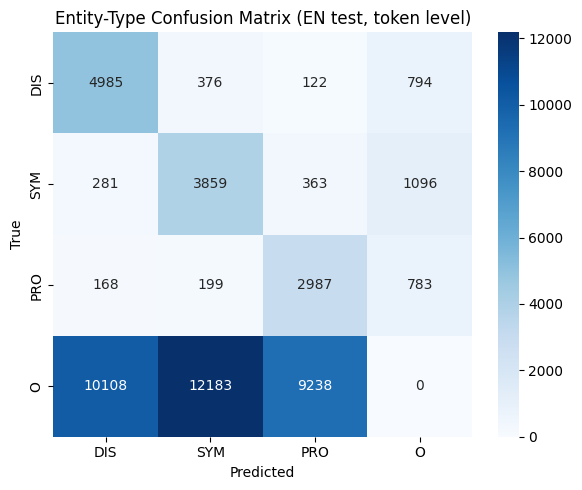

In [ ]:
def flatten_entity_tokens(true_seqs, pred_seqs):
    """Return flat lists of (true, pred) labels for non-O tokens only."""
    flat_true, flat_pred = [], []
    for ts, ps in zip(true_seqs, pred_seqs):
        for t, p in zip(ts, ps):
            if t != 'O' or p != 'O':  # include any token where true or pred is an entity
                # Normalise B-/I- prefix for confusion matrix (focus on type, not boundary)
                t_type = t[2:] if t != 'O' else 'O'
                p_type = p[2:] if p != 'O' else 'O'
                flat_true.append(t_type)
                flat_pred.append(p_type)
    return flat_true, flat_pred


en_ft, en_fp = flatten_entity_tokens(en_true, en_pred)
entity_labels = ['DIS', 'SYM', 'PRO', 'O']
cm = confusion_matrix(en_ft, en_fp, labels=entity_labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=entity_labels,
    yticklabels=entity_labels,
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Entity-Type Confusion Matrix (EN test, token level)')
plt.tight_layout()
cm_path = RESULTS_DIR / 'confusion_matrix_en.png'
plt.savefig(str(cm_path), dpi=150, bbox_inches='tight')
print(f'Saved: {cm_path}')
plt.show()

In [ ]:
import json

with open(RESULTS_DIR / 'en_test_results.json', 'w') as f:
    json.dump(en_report, f, indent=2)
with open(RESULTS_DIR / 'es_test_results.json', 'w') as f:
    json.dump(es_report, f, indent=2)

print(f'EN results saved → {RESULTS_DIR / "en_test_results.json"}')
print(f'ES results saved → {RESULTS_DIR / "es_test_results.json"}')

TypeError: Object of type int64 is not JSON serializable

In [ ]:
import sys
import os
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_from_disk
from transformers import (
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    Trainer,
)

from dataset import id2label, load_conll
from utils import tokenizer, get_data_paths

BEST_MODEL_PATH = REPO_ROOT / 'outputs' / 'checkpoints' / 'best_model'

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f'Best model not found at {BEST_MODEL_PATH}.\n'
        'Complete Phase 4 training first.'
    )

model = AutoModelForTokenClassification.from_pretrained(str(BEST_MODEL_PATH))
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print('Model loaded.')

In [ ]:
def get_predictions(lang, split='test'):
    """Return (sentences, true_labels, true_preds) for a language split."""
    train_f, dev_f, test_f = get_data_paths(lang)
    split_file = {'train': train_f, 'validation': dev_f, 'test': test_f}[split]
    sentences = load_conll(split_file)

    ds = load_from_disk(str(REPO_ROOT / 'data' / 'processed' / lang))
    preds_out = trainer.predict(ds[split])
    logits, labels = preds_out.predictions, preds_out.label_ids
    predictions = np.argmax(logits, axis=2)

    true_labels = [
        [id2label[l] for l in seq if l != -100]
        for seq in labels
    ]
    true_preds = [
        [id2label[p] for (p, l) in zip(ps, ls) if l != -100]
        for ps, ls in zip(predictions, labels)
    ]
    return sentences, true_labels, true_preds


def collect_errors(sentences, true_labels, true_preds):
    """Collect FP, FN, and type-confusion errors at the token level."""
    errors = {'false_positive': [], 'false_negative': [], 'type_confusion': []}
    for sent, ts, ps in zip(sentences, true_labels, true_preds):
        tokens = sent['tokens']
        context = ' '.join(tokens)
        for i, (t, p) in enumerate(zip(ts, ps)):
            token = tokens[i] if i < len(tokens) else ''
            if t == 'O' and p != 'O':
                errors['false_positive'].append({
                    'token': token,
                    'true':  t,
                    'pred':  p,
                    'context': context,
                })
            elif t != 'O' and p == 'O':
                errors['false_negative'].append({
                    'token': token,
                    'true':  t,
                    'pred':  p,
                    'context': context,
                })
            elif t != 'O' and p != 'O' and t != p:
                errors['type_confusion'].append({
                    'token': token,
                    'true':  t,
                    'pred':  p,
                    'context': context,
                })
    return errors


print('Running inference on EN test set ...')
en_sents, en_true, en_pred = get_predictions('en', 'test')
en_errors = collect_errors(en_sents, en_true, en_pred)

print('Running inference on ES test set ...')
es_sents, es_true, es_pred = get_predictions('es', 'test')
es_errors = collect_errors(es_sents, es_true, es_pred)

print('Error collection complete.')

In [ ]:
breakdown = pd.DataFrame({
    'Error Type':    ['False Positive', 'False Negative', 'Type Confusion'],
    'EN Count':      [len(en_errors['false_positive']),
                      len(en_errors['false_negative']),
                      len(en_errors['type_confusion'])],
    'ES Count':      [len(es_errors['false_positive']),
                      len(es_errors['false_negative']),
                      len(es_errors['type_confusion'])],
})
print('Error counts by category:')
display(breakdown)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(breakdown))
w = 0.35
ax.bar([i - w/2 for i in x], breakdown['EN Count'], width=w, label='EN', color='#4C72B0')
ax.bar([i + w/2 for i in x], breakdown['ES Count'], width=w, label='ES', color='#DD8452')
ax.set_xticks(list(x))
ax.set_xticklabels(breakdown['Error Type'])
ax.set_ylabel('Token count')
ax.set_title('Error Category Breakdown — EN vs ES')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(str(REPO_ROOT / 'outputs' / 'results' / 'error_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def show_errors(errors, category, n=10, lang='EN'):
    items = errors[category][:n]
    if not items:
        print(f'No {category} errors found.')
        return
    rows = [{'Token': e['token'], 'True': e['true'], 'Pred': e['pred'],
             'Context (truncated)': e['context'][:80]} for e in items]
    df = pd.DataFrame(rows)
    print(f'\n{lang} — {category.replace("_", " ").title()} (first {len(items)}):')
    display(df)


show_errors(en_errors, 'false_negative',  n=10, lang='EN')
show_errors(en_errors, 'false_positive',  n=10, lang='EN')
show_errors(en_errors, 'type_confusion',  n=10, lang='EN')

In [ ]:
show_errors(es_errors, 'false_negative',  n=10, lang='ES')
show_errors(es_errors, 'false_positive',  n=10, lang='ES')
show_errors(es_errors, 'type_confusion',  n=10, lang='ES')

In [ ]:
# Normalise by total entity tokens in each test set
def total_entity_tokens(label_seqs):
    return sum(1 for seq in label_seqs for l in seq if l != 'O')

en_entity_total = total_entity_tokens(en_true)
es_entity_total = total_entity_tokens(es_true)

rate_df = pd.DataFrame({
    'Error Type':   ['False Positive', 'False Negative', 'Type Confusion'],
    'EN Rate':      [
        round(len(en_errors['false_positive']) / max(en_entity_total, 1), 4),
        round(len(en_errors['false_negative']) / max(en_entity_total, 1), 4),
        round(len(en_errors['type_confusion']) / max(en_entity_total, 1), 4),
    ],
    'ES Rate':      [
        round(len(es_errors['false_positive']) / max(es_entity_total, 1), 4),
        round(len(es_errors['false_negative']) / max(es_entity_total, 1), 4),
        round(len(es_errors['type_confusion']) / max(es_entity_total, 1), 4),
    ],
})

print('Error rates (normalised by entity token count):')
display(rate_df)

In [ ]:
import os

def count_files_recursively(directory):
    """
    Counts the total number of files in a directory and its subdirectories.
    """
    count = 0
    for root, _, files in os.walk(directory):
        count += len(files)
    return count

# Example usage: count files in the current working directory
# You can change '.' to any other directory path you want to check
current_directory = '/content/extracted/MultiClinAI-training+NER_test_bg+CORPUS_test_bg_v1.3_260330'
file_count = count_files_recursively(current_directory)
print(f"Total number of files in '{current_directory}' and its subdirectories: {file_count}")

In [ ]:
!mv /content/MultiClinAI-training+NER_test_bg+CORPUS_test_bg_v1.3_260330 /content/MultiClinNER-XLMR/

In [ ]:
ls

dataset.zip  MultiClinAI-training+NER_test_bg+CORPUS_test_bg_v1.3_260330/
extracted/   sample_data/


In [ ]:
pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.3 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=28510e1698b249c148bb869b0f41d762cf19f7ffe322f5d8a9e1582cbcba6588
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widge